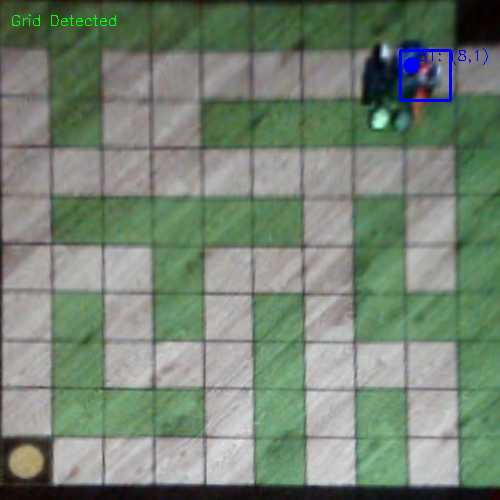

ConnectTimeout: HTTPConnectionPool(host='13.48.68.209', port=5000): Max retries exceeded with url: /push_positions (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x9906b5c8>, 'Connection to 13.48.68.209 timed out. (connect timeout=6.5)'))

In [ ]:
import cv2
import numpy as np
import asyncio
from pynq import Overlay
from pynq.lib.video import VideoMode
from pynq.lib.video.dma import AxiVDMA
from pynq import DefaultIP
from IPython.display import clear_output, display, Image


class CameraVDMA(AxiVDMA): # fixes an issue where interrupt pins were not being detected by creating software ones
    def __init__(self, description, framecount=3):
        DefaultIP.__init__(self, description)
        self.framecount = framecount
        params = description.get('parameters', {})
        has_s2mm = int(params.get('C_INCLUDE_S2MM', '0')) == 1
        has_mm2s = int(params.get('C_INCLUDE_MM2S', '0')) == 1
        memory = description["device"].default_memory
        if has_s2mm and not hasattr(self, 's2mm_introut'):
            self.s2mm_introut = asyncio.Event()
        if has_mm2s and not hasattr(self, 'mm2s_introut'):
            self.mm2s_introut = asyncio.Event()
        if has_s2mm:
            self.readchannel  = AxiVDMA.S2MMChannel(self, self.s2mm_introut, memory)
        if has_mm2s:
            self.writechannel = AxiVDMA.MM2SChannel(self, self.mm2s_introut, memory)

overlay = Overlay("downsampler_v5.bit")
overlay._ip_map._description['ip']['axi_vdma_0']['driver'] = CameraVDMA
vdma = CameraVDMA(overlay._ip_map._description['ip']['axi_vdma_0'])
vdma.writechannel.mode = VideoMode(640, 480, 24) # max resolution transmitted form usb
vdma.readchannel.mode  = VideoMode(320, 240, 24) # 75% reduction in pixel count
vdma.writechannel.start()
vdma.readchannel.start()

in_buffer  = vdma.writechannel._frames[0]
out_buffer = vdma.readchannel._frames[0]

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)
camera.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
camera.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

K = np.array([[250.0, 0.0, 160.0], [0.0, 250.0, 120.0], [0.0, 0.0, 1.0]]) # eliminates the curve of the camera by manually calibrating it
D = np.array([-0.1, 0.01, 0.0, 0.0, 0.0])
import requests
SERVER = 'http://13.48.68.209:5000' # to send x,y positions of blue stickers

def order_points(pts): # to ensure it knows which corner is which
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def pixel_to_grid(px, py, grid_size=10, image_size=500): # converts the pixels into a grid format
    cell = image_size / grid_size
    gx = int(px / cell)
    gy = int(py / cell)
    gx = max(0, min(grid_size - 1, gx))
    gy = max(0, min(grid_size - 1, gy))
    return gx, gy

def detect_blue(warped_frame): # finds the blue stickers and returns their x,y coordinates
    hsv = cv2.cvtColor(warped_frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([100, 70, 50]), np.array([130, 255, 255]))
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return []
    valid = sorted([c for c in contours if cv2.contourArea(c) > 30],
                   key=cv2.contourArea, reverse=True)[:3]
    results = []
    for c in valid:
        M = cv2.moments(c)
        if M['m00'] == 0:
            continue
        px = int(M['m10'] / M['m00'])
        py = int(M['m01'] / M['m00'])
        gx, gy = pixel_to_grid(px, py)
        results.append((px, py, (gx, gy)))
    return results

matrix_locked      = False
saved_matrix       = None
calibration_frames = 0
REQUIRED_FRAMES    = 30
accumulated_pts    = np.zeros((4, 2), dtype="float32")
blue_grid_pos      = None
cell               = 500 // 10 

try:
    while True:
        success, raw_frame = camera.read()
        if not success:
            break

        in_buffer[:] = raw_frame
        in_buffer.flush() # to ensure we are writing to RAM not cache
        out_buffer.invalidate() # to ensure we are reading from RAM not cache
        hw_frame = out_buffer[:, :, [0, 1, 2]] # downsampled image with RGB adjusted

        undistorted   = cv2.undistort(hw_frame, K, D)
        display_frame = undistorted.copy()

        if not matrix_locked: # find red stickers mode
            hsv  = cv2.cvtColor(undistorted, cv2.COLOR_BGR2HSV)
            mask = cv2.bitwise_or(
                cv2.inRange(hsv, np.array([0,   70, 50]), np.array([10,  255, 255])),
                cv2.inRange(hsv, np.array([170, 70, 50]), np.array([180, 255, 255])) # red goes over the spectrum so we need 2 ranges
            )
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            valid = sorted([c for c in contours if cv2.contourArea(c) > 2], # very small because small light distortions lead to them not being detected
                           key=cv2.contourArea, reverse=True)[:4]

            if len(valid) == 4:
                pts = []
                for c in valid:
                    M = cv2.moments(c)
                    if M['m00'] != 0:
                        pts.append([int(M['m10']/M['m00']), int(M['m01']/M['m00'])])

                ordered = order_points(np.array(pts))
                accumulated_pts    += ordered
                calibration_frames += 1

                for p in ordered:
                    cv2.circle(display_frame, (int(p[0]), int(p[1])), 5, (0, 255, 0), -1)
                cv2.putText(display_frame, f"Calibrating: {calibration_frames}/{REQUIRED_FRAMES}",
                            (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                if calibration_frames >= REQUIRED_FRAMES:
                    avg_pts      = accumulated_pts / REQUIRED_FRAMES
                    dst_pts      = np.array([[0,0],[499,0],[499,499],[0,499]], dtype="float32")
                    saved_matrix = cv2.getPerspectiveTransform(avg_pts, dst_pts)
                    matrix_locked = True # we are now calibrated
            else:
                calibration_frames = 0
                accumulated_pts.fill(0)
                cv2.putText(display_frame, "Searching for 4 red stickers",
                            (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        else: # find blue stickers mode
            display_frame = cv2.warpPerspective(undistorted, saved_matrix, (500, 500)) # warp our image into a 500x500 pixel grid acting as a top down view of the maze
            # this makes calculating the exact position of the blue stickers easier
            blue_objects = detect_blue(display_frame)
            if blue_objects:
                blue_grid_pos = [obj[2] for obj in blue_objects]
                requests.post(f'{SERVER}/push_positions',
                  json={'positions': [{'gx': gx, 'gy': gy} for (px, py, (gx, gy)) in blue_objects]}, # send to AWS
                  timeout=6.5) # high due to network issues
                for i, (px, py, (gx, gy)) in enumerate(blue_objects):
                    cv2.circle(display_frame, (px, py), 8, (255, 0, 0), -1)
                    cv2.rectangle(display_frame,
                                  (gx*cell, gy*cell),
                                  ((gx+1)*cell, (gy+1)*cell),
                                  (255, 0, 0), 2)
                    cv2.putText(display_frame, f"B{i+1}: ({gx},{gy})",
                                (px + 5, py - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

            cv2.putText(display_frame, "Blue sticker detected",
                        (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        _, encoded = cv2.imencode('.jpg', display_frame, [cv2.IMWRITE_JPEG_QUALITY, 50])
        clear_output(wait=True)
        display(Image(data=encoded.tobytes()))

finally:
    vdma.writechannel.stop()
    vdma.readchannel.stop()
    camera.release()
